In [3]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
from scipy.linalg import ishermitian, eigvals, eigvalsh
from scipy.sparse import kron, eye, diags, csc_matrix, hstack, vstack, random
from scipy.sparse.linalg import expm, expm_multiply, spsolve, norm
from utils import *
from linear_system_std_binary import *

from qiskit import QuantumCircuit, QuantumRegister, transpile
from qiskit.quantum_info import SparsePauliOp, operators
from qiskit import transpile
from qiskit import Aer
from ionq_circuit_utils import save_as_native_circuit, get_circuit_from_qiskit, get_native_circuit, get_native_gate_counts, get_ionq_job_json, send_job, cancel_job

# from pytket import OpType, Circuit
# from pytket.circuit import StatePreparationBox
# from pytket.passes import DecomposeBoxes, RebaseCustom, RemoveRedundancies, CommuteThroughMultis, RepeatPass, SequencePass, FullPeepholeOptimise, auto_rebase_pass
# from pytket.extensions.qiskit import qiskit_to_tk, tk_to_qiskit
# from pytket.circuit.display import render_circuit_jupyter

import hashlib
import json

from os.path import join

In [4]:
DATA_DIR = "experiment_data"
TASK_DIR = "linear_system_solver"

CURR_DIR = DATA_DIR
check_and_make_dir(CURR_DIR)
CURR_DIR = join(CURR_DIR, TASK_DIR)
check_and_make_dir(CURR_DIR)

print(CURR_DIR)

use_real_machine = False
if use_real_machine:
    device = "qpu.aria-1"
else:
    device = "simulator"
print("Device:", device)

experiment_data/linear_system_solver
Device: simulator


# Linear system solver by Schrodingerization

Generate linear system

In [17]:
'''Modifiable parameters'''
n_p = 6                         # Number of qubits for p
n_x = 2                         # Number of qubits for x
R = 6                           # Right boundary endpoint
T = 5.5                         # Evolution time
N_t = 16                        # Number of time points
r = 2                           # Number of Trotter steps
h_x = np.array([2, 3])          # Coefficients for single-qubit X terms in H_1
h_z = np.array([-2, -3])        # Coefficients for single-qubit Z terms in H_1
num_shots = 5000                # Number of shots
trotter_method = "second_order"
qft_approx_degree = 2


N_p = 2 ** n_p
h = (2 * R) / (N_p - 1)
p = np.linspace(-R, R, N_p)
print("N_p:", N_p)
print(f"Total number of qubits: {n_p + n_x}")

H_1 = sum_h_x(n=n_x, h=h_x) + sum_h_z(n=n_x, h=h_z)
H_1 -= H_1[-1,-1] * eye(2 ** n_x)
assert H_1[-1,-1] == 0
A = -H_1[:3,:3]
A_norm = np.linalg.norm(A.toarray(), ord=2)
H_1 /= A_norm
A /= A_norm
print("A:\n", A.toarray())
evals = eigvalsh(A.toarray())
print("Eigenvalues:", evals)
print(f"Condition number: {np.max(evals) / np.min(evals)}")
assert np.all(eigvalsh(A.toarray()) > 0)
b = 2 * H_1[:-1,-1]

print("b:\n", b.toarray())
A_tilde = vstack([hstack([-A, b]), csc_matrix((1, A.shape[0]+1))])
H_2 = (A_tilde - np.conj(A_tilde).T) / 2j

x_0 = csc_matrix(np.array([[0, 0, 0]]).T)
dimension = 3

x_sol = spsolve(A, b)
print("Ground truth:", x_sol)

N_p: 64
Total number of qubits: 8
A:
 [[ 0.84499602 -0.1689992  -0.25349881]
 [-0.1689992   0.50699761  0.        ]
 [-0.25349881  0.          0.33799841]]
Eigenvalues: [0.21672283 0.47326922 1.        ]
Condition number: 4.6141886213324
b:
 [[0.        ]
 [0.50699761]
 [0.33799841]]
Ground truth: [0.70588235 1.23529412 1.52941176]


In [18]:
experiment_info = {
    "n_p": n_p,
    "n_x": n_x,
    "R": R,
    "T": T,
    "N_t": N_t,
    "r": r,
    "h_x": h_x.tolist(),
    "h_z": h_z.tolist(),
    "num_shots": num_shots,
    "trotter_method": trotter_method,
    "qft_approx_degree": qft_approx_degree
}

hash_str = hashlib.md5(json.dumps(experiment_info).encode("utf-8")).hexdigest()
SAVE_DIR = join(CURR_DIR, hash_str)
check_and_make_dir(SAVE_DIR)

print("Save dir:", SAVE_DIR)

with open(join(SAVE_DIR, "experiment_info.json"), "w") as f:
    json.dump(experiment_info, f)
    f.close()

for i in range(N_t):
    if not exists(join(SAVE_DIR, f"t_{i}")):
        mkdir(join(SAVE_DIR, f"t_{i}"))

qpu_job_ids_filename = 'job_ids_qpu.json'

Save dir: experiment_data/linear_system_solver/7fa498e6148fe85220ee461fed011cee


In [19]:
u_recover = solve_gradient_flow(A, b, x_0, N_p, R, T, N_t, schrodingerization)
u_recover_ft = solve_gradient_flow(A, b, x_0, N_p, R, T, N_t, schrodingerization_ft)
u_recover_trot = solve_gradient_flow(A, b, x_0, N_p, R, T, N_t, schrodingerization_ft_trot, r=r)

print(f"Relative error (Schrodingerization): {np.linalg.norm(u_recover[-1,:] - x_sol) / np.linalg.norm(x_sol) : 0.3f}")
print(f"Relative error (Schrodingerization with FT): {np.linalg.norm(u_recover_ft[-1,:] - x_sol) / np.linalg.norm(x_sol) : 0.3f}")
# print(f"Relative error (Schrodingerization with FT, Trotter): {np.linalg.norm(u_recover_trot[-1,:] - x_sol) / np.linalg.norm(x_sol) : 0.3f}")

Eigvals of A_tilde:  [1.        +0.j 0.21672283+0.j 0.47326922+0.j 0.        +0.j]
Min eval: -0.1750044066688355
Eigvals of H1: [-1.02000043 -0.5419985  -0.30299753  0.17500441]
Eigvals of A_tilde:  [1.        +0.j 0.21672283+0.j 0.47326922+0.j 0.        +0.j]
Min eval: -0.1750044066688355
Eigvals of H1: [-1.02000043 -0.5419985  -0.30299753  0.17500441]
(256, 256)
Eigvals of A_tilde:  [1.        +0.j 0.21672283+0.j 0.47326922+0.j 0.        +0.j]
Min eval: -0.1750044066688355
Eigvals of H1: [-1.02000043 -0.5419985  -0.30299753  0.17500441]
Norm of diff:  0.00
Trotter error:  0.95
Relative error (Schrodingerization):  0.184
Relative error (Schrodingerization with FT):  0.180


In [20]:
circuit = get_full_circuit(n_x, n_p, T, H_1, H_2, r, R, trotter_method=trotter_method, qft_approx_degree=qft_approx_degree)
compiled_circuit = transpile(circuit, basis_gates=['rx', 'ry', 'rz', 'rxx', 'swap'], optimization_level=2)
print("Depth:", compiled_circuit.depth())
print(compiled_circuit.count_ops())

Depth: 80
OrderedDict([('rxx', 85), ('ry', 56), ('rz', 41), ('rx', 26), ('swap', 6)])


Ground truth

In [21]:
F_gf = lambda t, u: -A.toarray() @ u + b.toarray().reshape(dimension)

t_vals = np.linspace(0, T, N_t)
sol_gf = solve_ivp(F_gf, [0, T], x_0.toarray().reshape(dimension), t_eval=t_vals)

A_tilde = vstack([hstack([-A, b]), csc_matrix((1, A.shape[0]+1))])
# u_recover = schrodingerization(A_tilde, vstack([x_0, 1]), N, R, T, N_t, )

print(eigvals(A_tilde.toarray()))
print(eigvalsh((A_tilde + A_tilde.T).toarray() / 2))
F = lambda t, u: A_tilde @ u
t_vals = np.linspace(0, T, N_t)
sol_augmented = solve_ivp(F, [0, T], vstack([x_0, 1]).toarray().reshape(dimension+1), t_eval=t_vals)

[-1.        +0.j -0.21672283+0.j -0.47326922+0.j  0.        +0.j]
[-1.02000043 -0.5419985  -0.30299753  0.17500441]


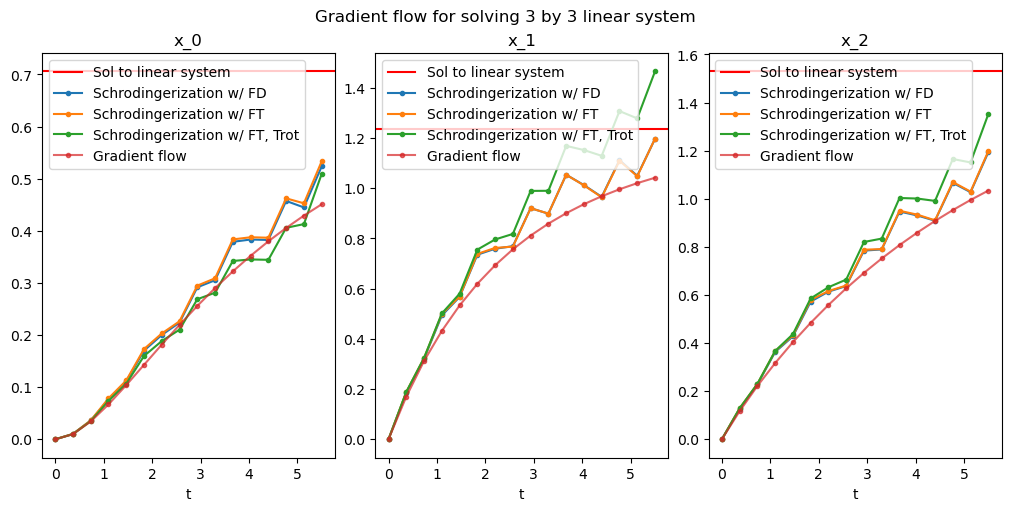

In [22]:
t_vals = np.linspace(0, T, N_t)

fig, axs = plt.subplots(1, dimension, constrained_layout=True, facecolor="white", figsize=(10,5))

aspect = 0.4

for i in range(3):
    
    axs[i].axhline(y=x_sol[i], color='red', label="Sol to linear system")

    axs[i].plot(t_vals, u_recover[:,i].real, '-o', label="Schrodingerization w/ FD", markersize=3)
    
    axs[i].plot(t_vals, u_recover_ft[:,i].real, '-o', label="Schrodingerization w/ FT", markersize=3)
    axs[i].plot(t_vals, u_recover_trot[:,i].real, '-o', label="Schrodingerization w/ FT, Trot", markersize=3)
    # axs[i].plot(t_vals, sol_augmented.y[i], '--o', label="scipy augmented ODE", linewidth=3, alpha=0.7)
    
    axs[i].plot(t_vals, sol_gf.y[i], '-o', label="Gradient flow", alpha=0.7, markersize=3)
    axs[i].legend()
    axs[i].set_title(f"x_{i}")
    axs[i].set_xlabel(f"t")
    # axs[i].set_ylim([-2, 2])
plt.suptitle(f"Gradient flow for solving {dimension} by {dimension} linear system")
plt.show()

Running t = 0.00
Running t = 0.37
Running t = 0.73
Running t = 1.10
Running t = 1.47
Running t = 1.83
Running t = 2.20
Running t = 2.57
Running t = 2.93
Running t = 3.30
Running t = 3.67
Running t = 4.03
Running t = 4.40
Running t = 4.77
Running t = 5.13
Running t = 5.50
Running t = 0.00
Running t = 0.37
Running t = 0.73
Running t = 1.10
Running t = 1.47
Running t = 1.83
Running t = 2.20
Running t = 2.57
Running t = 2.93
Running t = 3.30
Running t = 3.67
Running t = 4.03
Running t = 4.40
Running t = 4.77
Running t = 5.13
Running t = 5.50
Running t = 0.00
Running t = 0.37
Running t = 0.73
Running t = 1.10
Running t = 1.47
Running t = 1.83
Running t = 2.20
Running t = 2.57
Running t = 2.93
Running t = 3.30
Running t = 3.67
Running t = 4.03
Running t = 4.40
Running t = 4.77
Running t = 5.13
Running t = 5.50


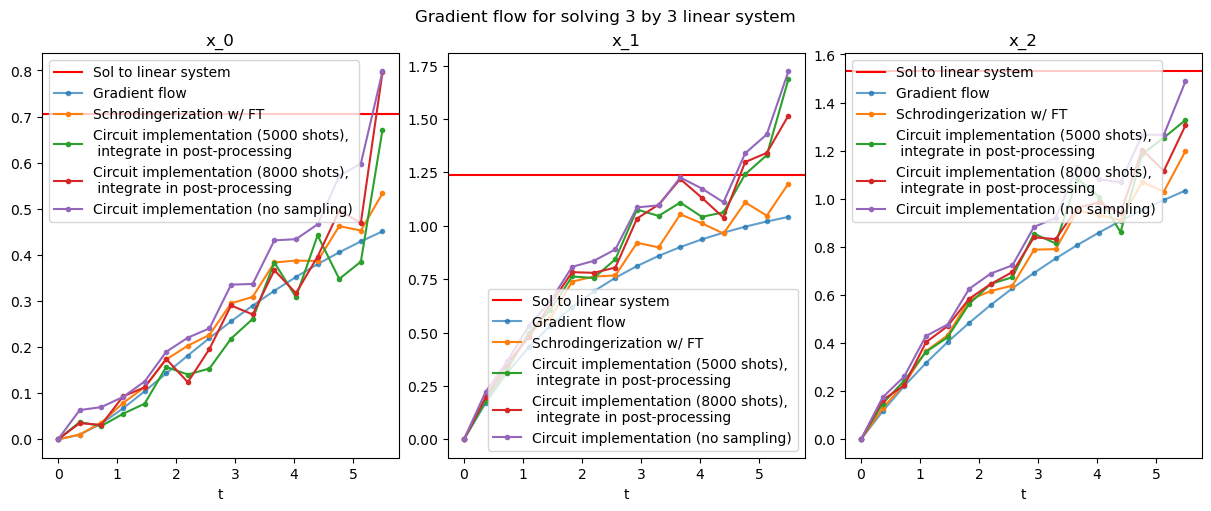

In [23]:
shots_vals = [5000, 8000]

t_vals = np.linspace(0, T, N_t)

fig, axs = plt.subplots(1, dimension, constrained_layout=True, facecolor="white", figsize=(12,5))

aspect = 0.4

for i in range(3):
    
    axs[i].axhline(y=x_sol[i], color='red', label="Sol to linear system")
    axs[i].plot(t_vals, sol_gf.y[i], '-o', label="Gradient flow", alpha=0.7, markersize=3)

    # axs[i].plot(t_vals, u_recover[:,i].real, '-o', label="Schrodingerization w/ FD", markersize=3)
    
    axs[i].plot(t_vals, u_recover_ft[:,i].real, '-o', label="Schrodingerization w/ FT", markersize=3)
    # axs[i].plot(t_vals, u_recover_trot[:,i].real, '-o', label="Schrodingerization w/ FT, Trot", markersize=3)
    # axs[i].plot(t_vals, sol_augmented.y[i], '--o', label="scipy augmented ODE", linewidth=3, alpha=0.7)
    # axs[i].plot(t_vals, u_recover_circ[:,i].real, '-o', label="Circuit implementation", markersize=3)
    
    axs[i].set_title(f"x_{i}")
    axs[i].set_xlabel(f"t")
    # axs[i].set_ylim([-2, 2])


# amplitude_vector = np.fft.fft(np.exp(-np.abs(p)), norm="ortho")
# normalization_factor = np.linalg.norm(amplitude_vector)
# Analytical approximation of normalization factor
normalization_factor_state_prep = np.sqrt((1 - np.exp(-2 * R)) / h)
n = n_x + n_p

for shots in shots_vals:
    u_recover_circ = np.zeros((N_t, dimension))
    for i, t in enumerate(t_vals):
        print(f"Running t ={t : 0.2f}")

        # Simulate with sampling
        circuit = get_full_circuit(n_x, n_p, t, H_1, H_2, r, R, trotter_method=trotter_method, qft_approx_degree=qft_approx_degree)
        circuit.measure_all()
        compiled_circuit = transpile(circuit, basis_gates=['rx', 'ry', 'rz', 'rxx', 'swap'], optimization_level=1)
        # print("Depth:", compiled_circuit.depth())
        # print(compiled_circuit.count_ops())

        # Run the quantum circuit on a statevector simulator backend
        backend = Aer.get_backend('statevector_simulator')
        job = backend.run(compiled_circuit, shots=shots)
        # job = backend.run(compiled_circuit)
        result = job.result()
        
        counts = result.get_counts(compiled_circuit)
        # print(result)
        dist_sim = np.zeros(2 ** n)
        for key in counts.keys():
            bitstring = np.zeros(n, dtype=int)
            for j in range(n):
                bitstring[j] = int(key[n-1-j])
            dist_sim[bitstring_to_int(bitstring)] = counts[key] / shots
        # plt.plot(dist_sim, label="sim")


        # # Simulate without sampling
        # circuit = get_full_circuit_naive_trotter(n_x, n_p, t, H_1, H_2, r)
        # compiled_circuit = transpile(circuit, basis_gates=['rx', 'ry', 'rz', 'rxx'], optimization_level=1)
        # # print("Depth:", compiled_circuit.depth())
        # # print(compiled_circuit.count_ops())

        # # Run the quantum circuit on a statevector simulator backend
        # backend = Aer.get_backend('statevector_simulator')
        # job = backend.run(compiled_circuit)
        # result = job.result()
        # output_state = np.array(result.get_statevector(compiled_circuit))
        # dist_ideal = np.abs(output_state)**2
        # plt.plot(dist_ideal, label="output")

        lambda_min = -norm(b)/2
        a = -lambda_min * t
        assert 0 <= a < R, "a is not within [0,R], increase R"
        a_idx = N_p // 2 + int(a / h)
        # u_recover[i] = np.exp(a) * np.sum(np.reshape(v, newshape=(N_t, dimension, N))[i,:,a_idx:], axis=1) * h
        u_recover_circ[i] = (normalization_factor_state_prep * np.exp(a) * np.sum(np.reshape(np.sqrt(dist_sim), newshape=(dimension + 1, N_p))[:,a_idx:], axis=1) * h)[:-1].real
        # plt.legend()
        # plt.show()

    for i in range(3):
        axs[i].plot(t_vals, u_recover_circ[:,i].real, '-o', label=f"Circuit implementation ({shots} shots),\n integrate in post-processing", markersize=3)


u_recover_circ = np.zeros((N_t, dimension))
for i, t in enumerate(t_vals):
    print(f"Running t ={t : 0.2f}")

    # Simulate without sampling
    circuit = get_full_circuit(n_x, n_p, t, H_1, H_2, r, R, trotter_method=trotter_method, qft_approx_degree=qft_approx_degree)
    compiled_circuit = transpile(circuit, basis_gates=['rx', 'ry', 'rz', 'rxx', 'swap'], optimization_level=1)
    # print("Depth:", compiled_circuit.depth())
    # print(compiled_circuit.count_ops())

    # Run the quantum circuit on a statevector simulator backend
    backend = Aer.get_backend('statevector_simulator')
    job = backend.run(compiled_circuit)
    result = job.result()
    output_state = np.array(result.get_statevector(compiled_circuit))
    dist_ideal = np.abs(output_state)**2

    lambda_min = -norm(b)/2
    a = -lambda_min * t
    assert 0 <= a < R, "a is not within [0,R], increase R"
    
    a_idx = N_p // 2 + int(a / h)
    # u_recover[i] = np.exp(a) * np.sum(np.reshape(v, newshape=(N_t, dimension, N))[i,:,a_idx:], axis=1) * h
    u_recover_circ[i] = (normalization_factor_state_prep * np.exp(a) * np.sum(np.reshape(np.sqrt(dist_ideal), newshape=(dimension + 1, N_p))[:,a_idx:], axis=1) * h)[:-1].real
    # plt.legend()
    # plt.show()
for i in range(3):
    axs[i].plot(t_vals, u_recover_circ[:,i].real, '-o', label=f"Circuit implementation (no sampling)", markersize=3)


for i in range(3):
    axs[i].legend()
plt.suptitle(f"Gradient flow for solving {dimension} by {dimension} linear system")
plt.show()

In [24]:
circuit = get_full_circuit(n_x, n_p, T, H_1, H_2, r, R, trotter_method=trotter_method, qft_approx_degree=qft_approx_degree)
# circuit.measure_all()
compiled_circuit, current_permutation = process_swaps(transpile(circuit, basis_gates=['rx', 'ry', 'rz', 'rxx', 'swap'], optimization_level=2))
print(compiled_circuit.count_ops())
# Check that SWAP gates are not removed by Qiskit transpiler
U1 = Operator(circuit).to_matrix()
U2 = Operator(compiled_circuit).to_matrix()
assert 1 - np.abs(np.trace(U1 @ np.conj(U2.T))) / 2 ** (n_p+n_x) < 1e-6, "Check compiled circuit matches the original circuit!"

OrderedDict([('rxx', 85), ('ry', 56), ('rz', 41), ('rx', 26)])


In [25]:
instructions = get_circuit_from_qiskit(compiled_circuit)
native_instructions, qubit_phase = get_native_circuit(n, instructions)
print(get_native_gate_counts(native_instructions))

(149, 85)


In [26]:
def run_linear_system_solver(experiment_info, device, save_dir, qpu_job_ids_filename):
    print("Running linear system solver")
    # Compute H_1 and H_2
    H_1 = sum_h_x(n=experiment_info["n_x"], h=experiment_info["h_x"]) + sum_h_z(n=experiment_info["n_x"], h=experiment_info["h_z"])
    H_1 -= H_1[-1,-1] * eye(2 ** experiment_info["n_x"])
    assert H_1[-1,-1] == 0
    A = -H_1[:3,:3]
    A_norm = np.linalg.norm(A.toarray(), ord=2)
    H_1 /= A_norm
    A /= A_norm
    print("A:\n", A.toarray())
    evals = eigvalsh(A.toarray())
    print("Eigenvalues:", evals)
    print(f"Condition number: {np.max(evals) / np.min(evals)}")
    assert np.all(eigvalsh(A.toarray()) > 0)
    b = 2 * H_1[:-1,-1]
    print("b:\n", b.toarray())
    A_tilde = vstack([hstack([-A, b]), csc_matrix((1, A.shape[0]+1))])
    H_2 = (A_tilde - np.conj(A_tilde).T) / 2j

    t_vals = np.linspace(0, experiment_info["T"], experiment_info["N_t"])
    job_ids = []
    for i, t in enumerate(t_vals):
        print(f"Running t = {t:0.2f}")

        # Get the circuit and transpile it, removing SWAP gates
        circuit = get_full_circuit(experiment_info["n_x"], 
                                   experiment_info["n_p"], 
                                   t, 
                                   H_1, 
                                   H_2, 
                                   experiment_info["r"], 
                                   experiment_info["R"],
                                   trotter_method=experiment_info["trotter_method"], 
                                   qft_approx_degree=experiment_info["qft_approx_degree"])

        compiled_circuit, current_permutation = process_swaps(transpile(circuit, basis_gates=['rx', 'ry', 'rz', 'rxx', 'swap'], optimization_level=2))
        assert current_permutation == list(range(experiment_info["n_x"]+experiment_info["n_p"]))

        # Check that SWAP gates do not affect the result when transpiled
        U1 = Operator(circuit).to_matrix()
        U2 = Operator(compiled_circuit).to_matrix()
        assert 1 - np.abs(np.trace(U1 @ np.conj(U2.T))) / 2 ** (experiment_info["n_x"]+experiment_info["n_p"]) < 1e-6, "Check compiled circuit matches the original circuit!"

        instructions = get_circuit_from_qiskit(compiled_circuit)
        native_instructions, qubit_phase = get_native_circuit(n, instructions)
        single_qubit_gates, two_qubit_gates = get_native_gate_counts(native_instructions)
        print(f"1q: {single_qubit_gates}, 2q: {two_qubit_gates}")
        
        # Create the job json and save it
        job = get_ionq_job_json("linear system solver", experiment_info["n_x"]+experiment_info["n_p"], experiment_info["num_shots"], device, instructions)
        
        print(f"Saving in {save_dir}")
        with open(join(save_dir, f"job_{i}.json"), "w") as f:
            json.dump(job, f, default=int)

        # Send the job and get the job id
        # job_id = send_job(job)
        # print("Job id:", job_id)
        # job_ids.append(job_id)

    print(f"Saving IonQ job ids as {qpu_job_ids_filename}")
    with open(join(save_dir, qpu_job_ids_filename), "w") as f:
        json.dump(job_ids, f)
        f.close()


Run on IonQ simulator or real machine

In [28]:
run_linear_system_solver(experiment_info, device, SAVE_DIR, qpu_job_ids_filename)

Running linear system solver
A:
 [[ 0.84499602 -0.1689992  -0.25349881]
 [-0.1689992   0.50699761  0.        ]
 [-0.25349881  0.          0.33799841]]
Eigenvalues: [0.21672283 0.47326922 1.        ]
Condition number: 4.6141886213324
b:
 [[0.        ]
 [0.50699761]
 [0.33799841]]
Running t = 0.00
1q: 94, 2q: 29
Saving in experiment_data/linear_system_solver/7fa498e6148fe85220ee461fed011cee
Running t = 0.37
1q: 117, 2q: 85
Saving in experiment_data/linear_system_solver/7fa498e6148fe85220ee461fed011cee
Running t = 0.73
1q: 117, 2q: 85
Saving in experiment_data/linear_system_solver/7fa498e6148fe85220ee461fed011cee
Running t = 1.10
1q: 125, 2q: 85
Saving in experiment_data/linear_system_solver/7fa498e6148fe85220ee461fed011cee
Running t = 1.47
1q: 125, 2q: 85
Saving in experiment_data/linear_system_solver/7fa498e6148fe85220ee461fed011cee
Running t = 1.83
1q: 133, 2q: 85
Saving in experiment_data/linear_system_solver/7fa498e6148fe85220ee461fed011cee
Running t = 2.20
1q: 141, 2q: 85
Saving in 

TODO: process the results

In [ ]:
# def process_results():
#     counts = result.get_counts(compiled_circuit)
#     # print(result)
#     dist_sim = np.zeros(2 ** n)
#     for key in counts.keys():
#         bitstring = np.zeros(n, dtype=int)
#         for j in range(n):
#             bitstring[j] = int(key[n-1-j])
#         dist_sim[bitstring_to_int(bitstring)] = counts[key] / shots
#     # plt.plot(dist_sim, label="sim")


#     # # Simulate without sampling
#     # circuit = get_full_circuit_naive_trotter(n_x, n_p, t, H_1, H_2, r)
#     # compiled_circuit = transpile(circuit, basis_gates=['rx', 'ry', 'rz', 'rxx'], optimization_level=1)
#     # # print("Depth:", compiled_circuit.depth())
#     # # print(compiled_circuit.count_ops())

#     # # Run the quantum circuit on a statevector simulator backend
#     # backend = Aer.get_backend('statevector_simulator')
#     # job = backend.run(compiled_circuit)
#     # result = job.result()
#     # output_state = np.array(result.get_statevector(compiled_circuit))
#     # dist_ideal = np.abs(output_state)**2
#     # plt.plot(dist_ideal, label="output")

#     lambda_min = -norm(b)/2
#     a = -lambda_min * t
#     assert 0 <= a < R, "a is not within [0,R], increase R"
#     a_idx = N_p // 2 + int(a / h)
#     # u_recover[i] = np.exp(a) * np.sum(np.reshape(v, newshape=(N_t, dimension, N))[i,:,a_idx:], axis=1) * h
#     u_recover_circ[i] = (normalization_factor_state_prep * np.exp(a) * np.sum(np.reshape(np.sqrt(dist_sim), newshape=(dimension + 1, N_p))[:,a_idx:], axis=1) * h)[:-1].real
#     # plt.legend()
#     # plt.show()